# Hoe wordt een JPEG data?

Van luchtfoto-bestand naar getallen — de basis onder de hele pipeline. Dit notebook
haalt zelf één demo-tegel op bij PDOK (paar honderd KB), dus het werkt overal.

Korte antwoorden vooraf:
- **Ja**: een foto wordt een blok getallen — per pixel drie waarden (rood, groen, blauw),
  elk 0–255.
- **Maar**: het JPEG-bestand zelf is *gecomprimeerde* data; pas bij het openen wordt het
  dat getallenblok. Hieronder zie je beide vormen.

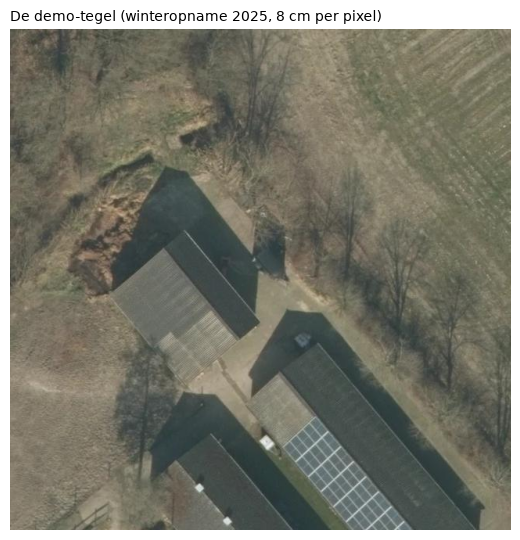

In [1]:
import io, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter

REPO = Path.cwd().resolve()
if REPO.name == 'notebooks':
    REPO = REPO.parent
sys.path.insert(0, str(REPO / 'scripts'))
from pdok import make_session, wms_get_map

WMS = 'https://service.pdok.nl/hwh/luchtfotorgb/wms/v1_0'
DEMO_BBOX = (103756.0, 396500.0, 103807.2, 396551.2)   # schuren in Etten-Leur, 51,2 x 51,2 m
sessie = make_session()

jpeg_bytes = wms_get_map(sessie, WMS, '2025_orthoHR', DEMO_BBOX, 640, 640)
beeld = Image.open(io.BytesIO(jpeg_bytes)).convert('RGB')

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(beeld); ax.axis('off')
ax.set_title('De demo-tegel (winteropname 2025, 8 cm per pixel)', fontsize=10, loc='left')
plt.tight_layout(); plt.show()

## 1. Op schijf: gecomprimeerde bytes

Een JPEG-bestand is géén tabel met pixelwaarden, maar een slim samengeperste beschrijving
ervan (daarover meer in sectie 6). Je herkent een JPEG aan de eerste bytes: `FF D8 FF`.

In [2]:
print(f'Bestandsgrootte: {len(jpeg_bytes):,} bytes ({len(jpeg_bytes)/1024:.0f} kB)')
print('Eerste 16 bytes (hex):', jpeg_bytes[:16].hex(' '))
print('Dat is dus onleesbaar totdat een JPEG-decoder er pixels van maakt.')

Bestandsgrootte: 52,723 bytes (51 kB)
Eerste 16 bytes (hex): ff d8 ff e0 00 10 4a 46 49 46 00 01 01 00 00 01
Dat is dus onleesbaar totdat een JPEG-decoder er pixels van maakt.


## 2. Na het openen: een blok getallen

`Image.open` decodeert het bestand; `np.asarray` maakt er een rekenbaar blok van:
**hoogte × breedte × 3 kanalen** (rood, groen, blauw), elke waarde een geheel getal 0–255
(0 = geen licht in dat kanaal, 255 = maximaal).

In [3]:
arr = np.asarray(beeld)
print(f'Vorm van het blok: {arr.shape}  (rijen, kolommen, kanalen)')
print(f'Datatype: {arr.dtype}  (geheel getal 0-255)')
print(f'Totaal aantal getallen: {arr.size:,}  — dat was op schijf {len(jpeg_bytes):,} bytes,')
print(f'de compressie maakt het bestand dus ~{arr.size/len(jpeg_bytes):.0f}x kleiner.\n')
rij, kolom = 320, 400
r, g, b = arr[rij, kolom]
print(f'Voorbeeld: pixel op rij {rij}, kolom {kolom} heeft (R, G, B) = ({r}, {g}, {b})')
print('Die ene pixel beslaat 8 x 8 cm grond.')

Vorm van het blok: (640, 640, 3)  (rijen, kolommen, kanalen)
Datatype: uint8  (geheel getal 0-255)
Totaal aantal getallen: 1,228,800  — dat was op schijf 52,723 bytes,
de compressie maakt het bestand dus ~23x kleiner.

Voorbeeld: pixel op rij 320, kolom 400 heeft (R, G, B) = (112, 106, 92)
Die ene pixel beslaat 8 x 8 cm grond.


## 3. De drie kanalen apart

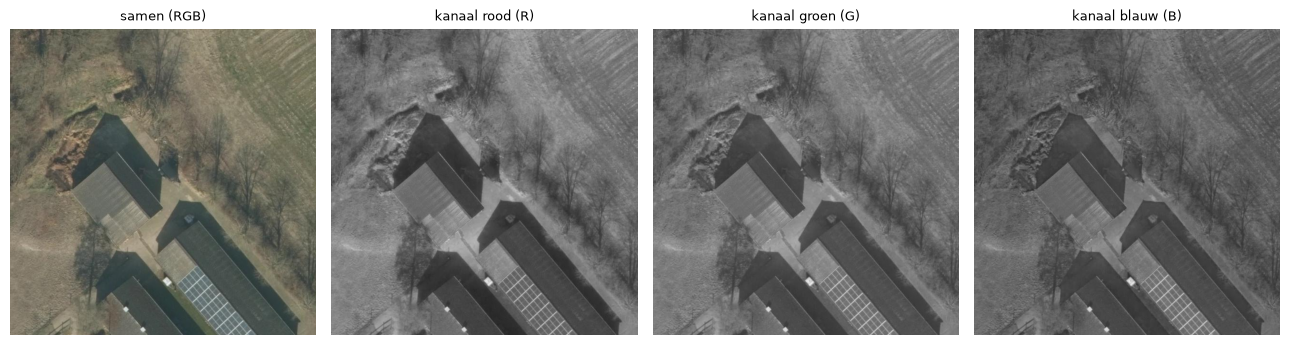

Elk kanaal is zelf een grijs plaatje: licht = veel van die kleur.
Let op het gras: dat is licht in het groene kanaal, donkerder in blauw.


In [4]:
fig, assen = plt.subplots(1, 4, figsize=(13, 3.6))
assen[0].imshow(beeld); assen[0].set_title('samen (RGB)', fontsize=9)
for i, naam in enumerate(('rood (R)', 'groen (G)', 'blauw (B)')):
    assen[i + 1].imshow(arr[:, :, i], cmap='gray', vmin=0, vmax=255)
    assen[i + 1].set_title(f'kanaal {naam}', fontsize=9)
for ax in assen:
    ax.axis('off')
plt.tight_layout(); plt.show()
print('Elk kanaal is zelf een grijs plaatje: licht = veel van die kleur.')
print('Let op het gras: dat is licht in het groene kanaal, donkerder in blauw.')

## 4. Inzoomen tot je de getallen ziet

Een uitsnede van 8 × 8 pixels (64 × 64 cm grond) met de grijswaarde in elk vakje —
dit is letterlijk wat het rekenwerk "ziet".

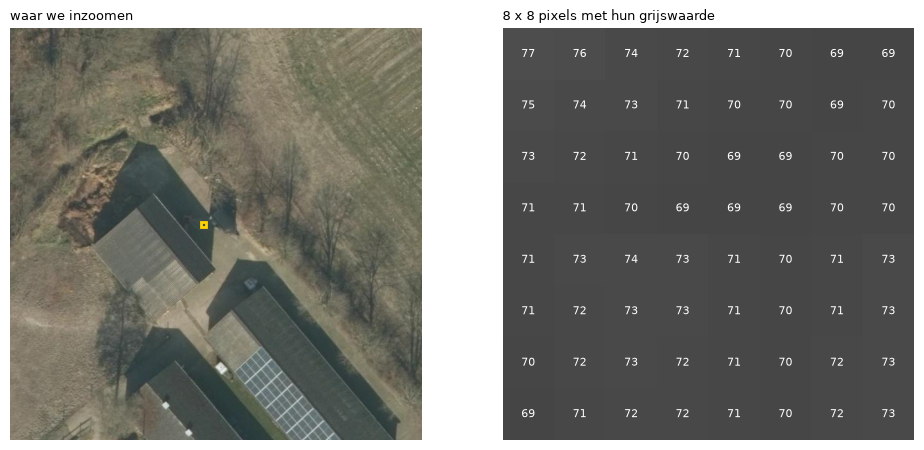

In [5]:
grijs = np.asarray(beeld.convert('L'))
y0, x0 = 300, 296   # randje van een dak
blokje = grijs[y0:y0 + 8, x0:x0 + 8]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.6))
ax1.imshow(beeld); ax1.axis('off')
ax1.add_patch(plt.Rectangle((x0, y0), 8, 8, fill=False, edgecolor='#FFD400', linewidth=2))
ax1.set_title('waar we inzoomen', fontsize=9, loc='left')
ax2.imshow(blokje, cmap='gray', vmin=0, vmax=255)
for i in range(8):
    for j in range(8):
        ax2.text(j, i, str(blokje[i, j]), ha='center', va='center', fontsize=8,
                 color='black' if blokje[i, j] > 128 else 'white')
ax2.set_title('8 x 8 pixels met hun grijswaarde', fontsize=9, loc='left')
ax2.axis('off')
plt.tight_layout(); plt.show()

## 5. Van RGB naar grijs, en waarom normaliseren

De verschilscore werkt op grijswaarden: één getal per pixel in plaats van drie.
De standaardformule weegt de kanalen naar hoe gevoelig het menselijk oog is:

$$\text{grijs} = 0{,}299 \cdot R + 0{,}587 \cdot G + 0{,}114 \cdot B$$

Daarna normaliseren we (gemiddelde eraf, delen door de spreiding) zodat een donkerdere
opnamedag niet als "verandering" telt — kijk wat dat met de verdeling doet:

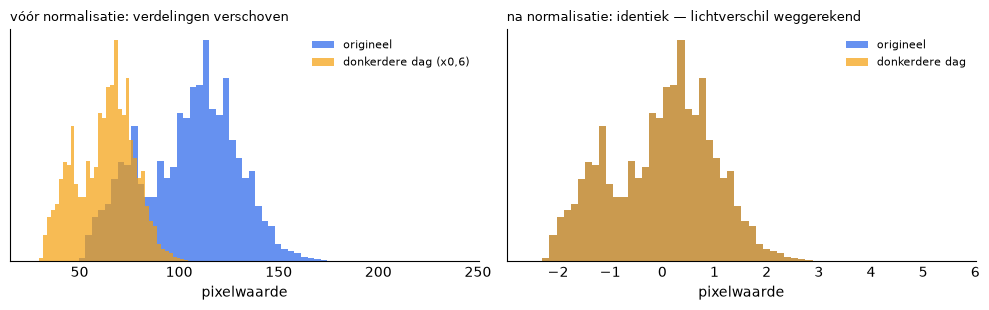

max verschil tussen de twee genormaliseerde versies: 0.000000


In [6]:
g = grijs.astype(np.float32)
donker = g * 0.6          # nagebootste donkerdere opnamedag: alle pixels 40% dimmen
def z(a):
    return (a - a.mean()) / (a.std() + 1e-6)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2))
ax1.hist(g.ravel(), bins=60, color='#2563EB', alpha=0.7, label='origineel')
ax1.hist(donker.ravel(), bins=60, color='#F59E0B', alpha=0.7, label='donkerdere dag (x0,6)')
ax1.set_title('vóór normalisatie: verdelingen verschoven', fontsize=9, loc='left')
ax1.legend(frameon=False, fontsize=8)
ax2.hist(z(g).ravel(), bins=60, color='#2563EB', alpha=0.7, label='origineel')
ax2.hist(z(donker).ravel(), bins=60, color='#F59E0B', alpha=0.7, label='donkerdere dag')
ax2.set_title('na normalisatie: identiek — lichtverschil weggerekend', fontsize=9, loc='left')
ax2.legend(frameon=False, fontsize=8)
for ax in (ax1, ax2):
    ax.set_xlabel('pixelwaarde'); ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(length=0); ax.set_yticks([])
plt.tight_layout(); plt.show()
print(f'max verschil tussen de twee genormaliseerde versies: {np.abs(z(g) - z(donker)).max():.6f}')

## 6. Waarom JPEG "lossy" is (en waarom we blurren)

JPEG comprimeert per blokje van 8 × 8 pixels en gooit details weg die het oog toch
amper ziet. Bij lage kwaliteit zie je die blokjes terug. Twee jaargangen zijn met
verschillende instellingen verwerkt — óók dat geeft kleine pixelverschillen zonder
echte verandering, en dat is (naast ruis) precies waarom de verschilscore eerst
licht blurt.

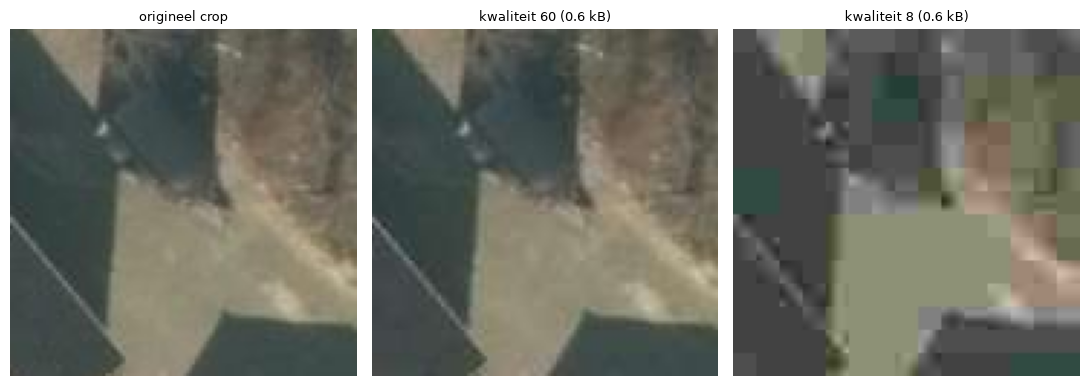

In [7]:
def hercomprimeer(img, kwaliteit):
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=kwaliteit)
    return Image.open(buf), buf.tell()

crop = beeld.crop((280, 260, 400, 380))
fig, assen = plt.subplots(1, 3, figsize=(11, 4))
for ax, kwaliteit in zip(assen[1:], (60, 8)):
    klein, n_bytes = hercomprimeer(crop, kwaliteit)
    ax.imshow(klein); ax.set_title(f'kwaliteit {kwaliteit} ({n_bytes/1024:.1f} kB)', fontsize=9)
assen[0].imshow(crop); assen[0].set_title('origineel crop', fontsize=9)
for ax in assen:
    ax.axis('off')
plt.tight_layout(); plt.show()

## Samengevat

1. **Op schijf**: JPEG = gecomprimeerde bytes (~30x kleiner dan de pixels).
2. **Na openen**: een blok van 640 × 640 × 3 getallen (0–255) — ja, RGB-waarden voor
   álle pixels, en elke pixel is 8 × 8 cm grond.
3. **De verschilscore** rekent daarna: RGB → grijs → blur → normaliseren → aftrekken
   in verschuivingen ([docs/verschilscore-techniek.md](../docs/verschilscore-techniek.md)).
4. **Het YOLO-model** eet hetzelfde blok, alleen dan als RGB geschaald naar 0–1, en
   leert zelf welke getalpatronen "zonnepaneel" of "dakkapel" betekenen.

*Bevat gegevens van PDOK: Luchtfoto Beeldmateriaal Nederland (CC-BY 4.0).*